# Neuron and Activation Functions

Foundations notebook — understanding the building block of every neural network before touching Keras.

## From Biological to Mathematical Neuron

A biological neuron receives signals through dendrites, combines them in the cell body, and fires an output through the axon if the combined signal is strong enough.

In 1943, McCulloch and Pitts proposed the first mathematical model of a neuron (the **MP Model**):

- Takes multiple binary inputs
- Sums them (optionally with weights)
- Fires (outputs 1) if the sum crosses a threshold, else outputs 0

This is the ancestor of every neuron used in modern deep learning. The modern version replaces the hard threshold with a smooth **activation function**, and adds **learnable weights and bias** instead of fixed ones.

**Modern artificial neuron:**

$$z = (w_1 x_1 + w_2 x_2 + ... + w_n x_n) + b$$
$$output = activation(z)$$

Where:
- $x_1, x_2, ..., x_n$ — inputs
- $w_1, w_2, ..., w_n$ — weights (importance of each input, learned during training)
- $b$ — bias (shifts the decision boundary)
- $activation$ — function applied to $z$ to introduce non-linearity

## Worked Example

A neuron with 3 inputs (hours studied, hours slept, practice tests taken), predicting whether a student passes.

- Inputs: $x = [6, 7, 3]$
- Weights: $w = [0.5, 0.3, 0.8]$
- Bias: $b = -5$

$$z = (0.5 \times 6) + (0.3 \times 7) + (0.8 \times 3) - 5 = 2.5$$

This $z$ then passes through an activation function to produce the final output.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([6, 7, 3])
w = np.array([0.5, 0.3, 0.8])
b = -5

z = np.dot(w, x) + b
print("z - " ,z)

z -  2.5


## Why Activation Functions Are Needed

Without an activation function, a neuron just computes a linear combination. Stacking multiple linear layers still collapses into a single linear function, no matter how many layers you add.

Proof by example:
- Layer 1: $z_1 = w_1 x + b_1$
- Layer 2: $z_2 = w_2 z_1 + b_2 = w_2 (w_1 x + b_1) + b_2 = (w_2 w_1) x + (w_2 b_1 + b_2)$

This is still of the form $Wx + B$ — a single linear layer. Depth adds nothing without non-linearity.

Activation functions introduce non-linearity so networks can learn complex patterns like image edges, language structure, or non-linear decision boundaries.

In [4]:
w1, b1 = 2, 1
w2, b2 = 3, -2

x = 5
z1 = w1 * x + b1
z2 = w2 * x + b2
print("Two linear layers stacked:", z2)

w_equiv = w2 * w1
b_equiv = w2 * b1 + b2
print("Single equivalent linear layer:", w_equiv * x + b_equiv)

Two linear layers stacked: 13
Single equivalent linear layer: 31


## Step Function

The original MP model activation. Outputs 1 if input crosses a threshold, else 0.

$$f(z) = \begin{cases} 1 & z \geq 0 \\ 0 & z < 0 \end{cases}$$

Rarely used today — it's non-differentiable (zero gradient everywhere except the jump), so it can't be used with gradient descent.

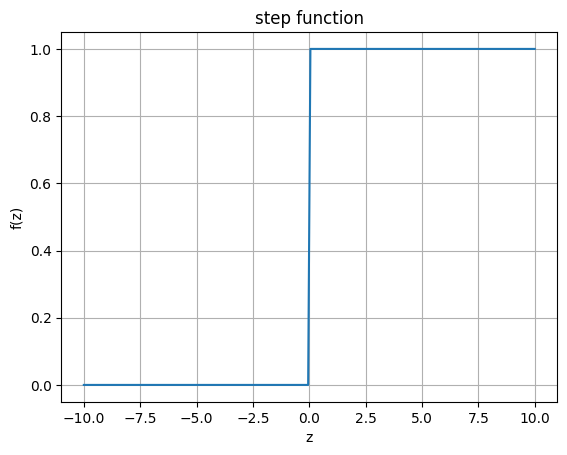

In [10]:
def step(z):
  return np.where(z >= 0, 1, 0)

z = np.linspace(-10, 10, 200)
plt.plot(z, step(z))
plt.title("step function")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.grid(True)
plt.show()

## Sigmoid

Squashes any real number into the range (0, 1). Historically the default choice for hidden layers, now mostly used in output layers for binary classification.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Derivative (needed for backprop later):

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Downside: for large positive or negative $z$, the gradient is near zero — the "vanishing gradient" problem.

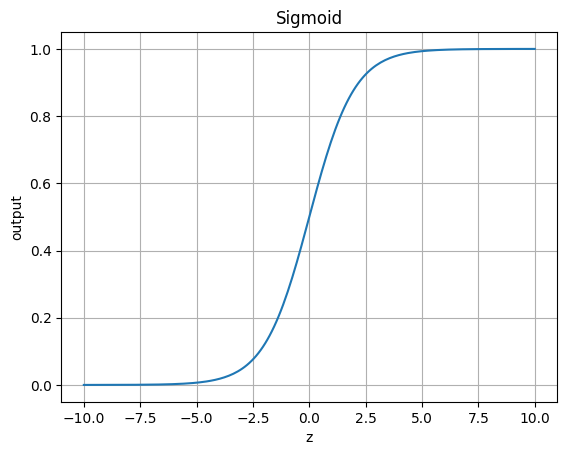

In [6]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.title("Sigmoid")
plt.xlabel("z")
plt.ylabel("output")
plt.grid(True)
plt.show()

## Tanh

Like sigmoid but outputs range (-1, 1), centered at 0. Zero-centered output helps gradients flow better than sigmoid, so it's often preferred in hidden layers over sigmoid.

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

Still suffers from vanishing gradients at extreme values, just less severely than sigmoid.

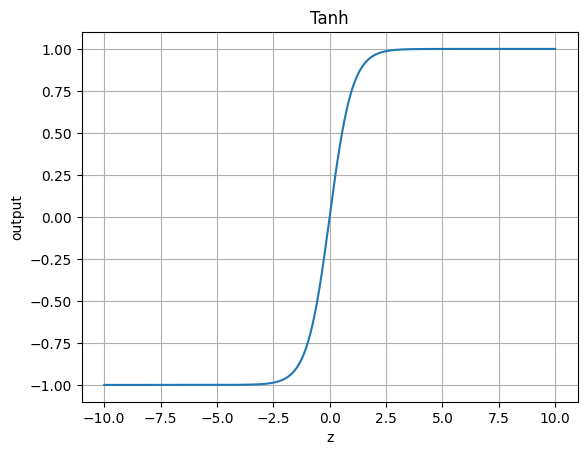

In [7]:
def tanh(z):
    return np.tanh(z)

z = np.linspace(-10, 10, 200)
plt.plot(z, tanh(z))
plt.title("Tanh")
plt.xlabel("z")
plt.ylabel("output")
plt.grid(True)
plt.show()

## ReLU (Rectified Linear Unit)

The most widely used activation in hidden layers today. Simple, fast to compute, and avoids vanishing gradients for positive inputs.

$$f(z) = \max(0, z)$$

Downside: "dying ReLU" — if a neuron's weights push $z$ negative for all inputs, its gradient becomes permanently 0 and it stops learning.

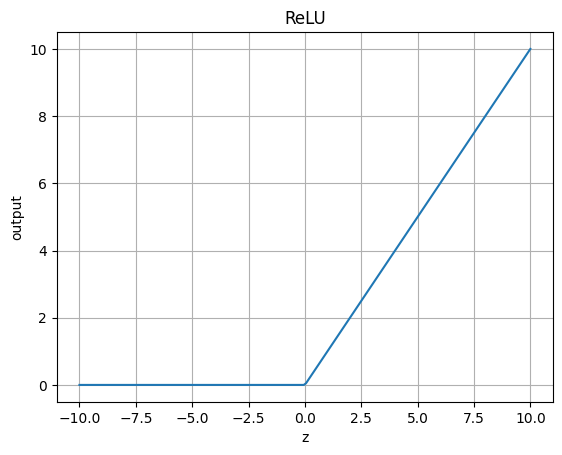

In [8]:
def relu(z):
    return np.maximum(0, z)

z = np.linspace(-10, 10, 200)
plt.plot(z, relu(z))
plt.title("ReLU")
plt.xlabel("z")
plt.ylabel("output")
plt.grid(True)
plt.show()

## Leaky ReLU

Fixes the dying ReLU problem by allowing a small, non-zero gradient when $z < 0$.

$$f(z) = \begin{cases} z & z \geq 0 \\ \alpha z & z < 0 \end{cases}$$

where $\alpha$ is a small constant, typically 0.01.

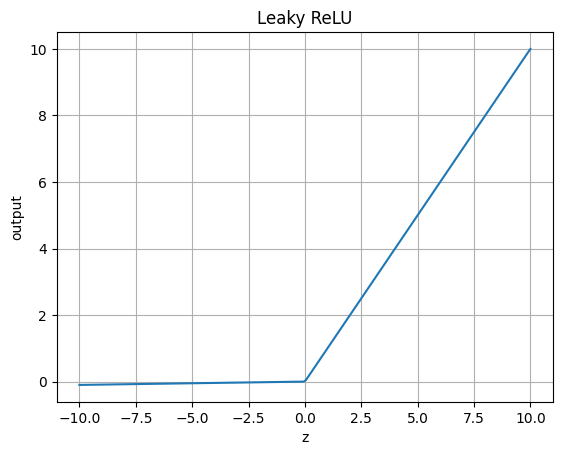

In [9]:
def leaky_relu(z, alpha=0.01):
    return np.where(z >= 0, z, alpha * z)

z = np.linspace(-10, 10, 200)
plt.plot(z, leaky_relu(z))
plt.title("Leaky ReLU")
plt.xlabel("z")
plt.ylabel("output")
plt.grid(True)
plt.show()

## Softmax

Used in the output layer for multi-class classification. Converts a vector of raw scores (logits) into a probability distribution — all outputs are between 0 and 1 and sum to 1.

$$softmax(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

In [11]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # subtract max for numerical stability
    return exp_z / np.sum(exp_z)

logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)
print("Logits:", logits)
print("Probabilities:", probs)
print("Sum of probabilities:", np.sum(probs))

Logits: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0


## Comparing All Activation Functions

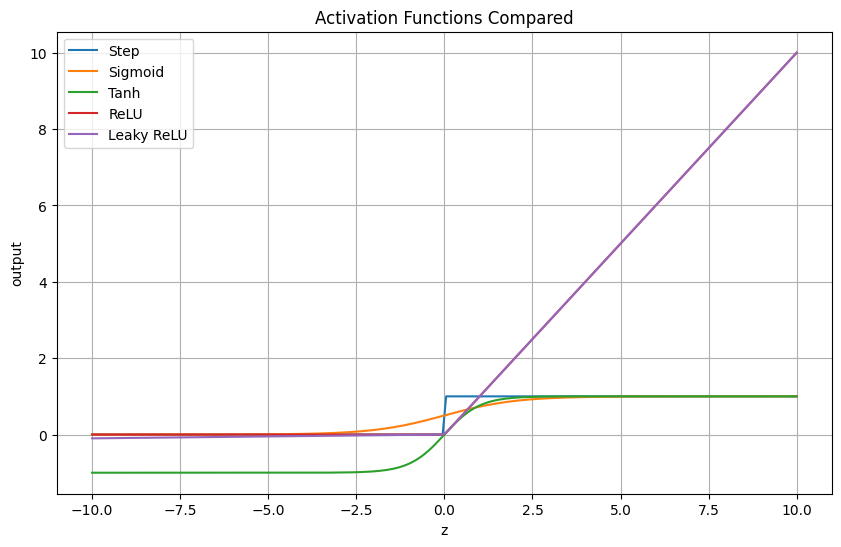

In [12]:
z = np.linspace(-10, 10, 200)

plt.figure(figsize=(10, 6))
plt.plot(z, step(z), label="Step")
plt.plot(z, sigmoid(z), label="Sigmoid")
plt.plot(z, tanh(z), label="Tanh")
plt.plot(z, relu(z), label="ReLU")
plt.plot(z, leaky_relu(z), label="Leaky ReLU")
plt.title("Activation Functions Compared")
plt.xlabel("z")
plt.ylabel("output")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

Neurons compute a weighted sum plus bias, then apply an activation function to introduce non-linearity — without which depth is meaningless.